# 03-03 - Planning the Flight by Strips

On Wednesday 23 September a drone flies over Poe Field and takes about a hundred photographs. Nobody guesses that number. It follows, along with the altitude, the distance between photographs, the distance between strips and the time in the air, from five numbers about the camera, two percentages about overlap, and the outline of the field. This notebook computes the whole plan from those inputs, so that on Wednesday the plan is yours and not a setting somebody else typed into an app.

We start with the camera as a central projection and derive the ground sample distance, the size of one pixel on the ground, from the pixel on the sensor, the focal length and the height. We turn two overlaps into a base and a strip spacing, lay strips along the long side of the field, count photographs, and draw the plan on last summer's aerial photograph. We count how many photographs see each square metre of the lawn at two different overlaps, and we look at what the extra photographs buy in leaning buildings and height precision, and at what a flight without ground control gives up. Then you replan the same flight for a different height and a different camera mode, which is what a pilot does every time the weather changes.

Every function here is a few lines, and every number it produces is printed beside the number the lecture quoted, which the kit carries in `ground_truth.json` so that nothing is typed twice. Before you run anything, choose *File*, then *Save As*, and give the copy a name with `-mywork` in it, so that next week's pull never collides with your work.

In [1]:
import json
import math

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio import features
from rasterio.transform import from_origin
from shapely.geometry import LineString, Point, box
from shapely.affinity import rotate
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 72

## The camera in five numbers

The aircraft is a DJI Mini 3. Its camera has a sensor whose pixels are 2.4 micrometres apart, behind a lens of 6.72 millimetres focal length, and in the mode we fly it reads 4000 by 3000 of those pixels, twelve million in all. The same camera can also be set to a 16:9 picture of 4000 by 2250 pixels, which throws away a quarter of the frame, and the pre-flight was flown that way by mistake; 03-05 reads the consequence off the photographs. Those are the only camera facts the plan needs, together with the shortest interval at which it will take timed photographs, plus the height above the ground we choose to fly at, 80 m, and the ceiling the regulations impose, 400 feet.

A camera is a central projection: every ray from the ground passes through one point, the lens, and lands on the sensor behind it. Two similar triangles, one from the lens down to the ground and one from the lens back to the sensor, give the scale of the photograph as the focal length over the height, and therefore the size of one pixel on the ground as the size of one pixel on the sensor times the height over the focal length. That is the ground sample distance, GSD, and everything else in this notebook is built on it:

In [2]:
MINI_3 = dict(pixel_um=2.4, focal_mm=6.72, width_px=4000, height_px=3000, min_interval_s=2)
ALTITUDE_M = 80.0
CEILING_M = 400 * 0.3048          # Part 107 allows 400 feet above the ground

def gsd(h, cam=MINI_3):
    '''The ground sample distance in metres at height h: the pixel, times the height, over the focal length.'''
    return cam["pixel_um"] * 1e-6 * h / (cam["focal_mm"] * 1e-3)

def footprint(h, cam=MINI_3):
    '''What one photograph covers on the ground, in metres, the long side of the image first.'''
    return cam["width_px"] * gsd(h, cam), cam["height_px"] * gsd(h, cam)

reference = json.load(open("data/ground_truth.json"))["p03"]
for h in (60, 80, 100, 120):
    across, along = footprint(h)
    ref_fp = reference["camera"]["footprint_m"] if h == ALTITUDE_M else None
    print(f"at {h:3d} m: GSD {gsd(h) * 100:.2f} cm, one photograph covers {across:.0f} by {along:.0f} m"
          f"   reference {reference['camera']['gsd_cm'][str(h)]} cm" + (f", {ref_fp[0]} by {ref_fp[1]} m" if ref_fp else ""))
print(f"the ceiling is {CEILING_M:.1f} m above the ground; the scale at {ALTITUDE_M:.0f} m is 1:{ALTITUDE_M / (MINI_3['focal_mm'] * 1e-3):,.0f}")

at  60 m: GSD 2.14 cm, one photograph covers 86 by 64 m   reference 2.14 cm
at  80 m: GSD 2.86 cm, one photograph covers 114 by 86 m   reference 2.86 cm, 114.3 by 85.7 m
at 100 m: GSD 3.57 cm, one photograph covers 143 by 107 m   reference 3.57 cm
at 120 m: GSD 4.29 cm, one photograph covers 171 by 129 m   reference 4.29 cm
the ceiling is 121.9 m above the ground; the scale at 80 m is 1:11,905


At 80 m every pixel is 2.86 cm on the ground and one photograph covers about 114 by 86 m, which is very nearly the whole width of the field in a single frame and nowhere near its length. Fly at 60 m and the pixel shrinks to 2.14 cm and the photograph covers less, so more photographs are needed. Fly at 120 m, just under the legal ceiling, and the pixel is 4.3 cm. The GSD grows in proportion to the height because the two triangles are similar, and that is the one trade a pilot makes before anything else: detail against coverage, with the law setting the upper end.

One more convention hides in `footprint`. The photograph's long side, 4000 pixels, lies across the direction of flight, because the camera hangs under the aircraft with the top of the picture pointing forward. So a photograph covers 114 m across the strip and 86 m along it, and the two overlaps below refer to those two directions. On Wednesday the yaw recorded in every photograph will tell us whether that was true.

## Base, spacing, density

Photogrammetry needs every point of the ground in at least two photographs, so consecutive photographs overlap along the strip, and neighbouring strips overlap sideways. The classical rule, from the days of film, was 60 percent forward and 30 percent sideways. Software that matches millions of points prefers far more, 80 percent forward and 60 to 70 percent sideways, and Wednesday flies 80 and 70.

Overlap is a percentage of the footprint, so it converts directly into distances. The base is the distance between photographs along the strip, the footprint's along side times what is left after the forward overlap. The spacing is the distance between strips, the across side times what is left after the side overlap. Their product is the neat area, the ground each new photograph adds that no earlier photograph covered, and a square kilometre divided by the neat area is how many photographs a square kilometre costs:

In [3]:
def densities(h, forward, side, cam=MINI_3):
    '''From the two overlaps in percent: the base between photographs along a strip, the spacing between strips,
    the neat area each new photograph adds, how many photographs a square kilometre costs, the base to height
    ratio that decides the strength of a stereo pair, and how many photographs see a point away from the edges.'''
    across, along = footprint(h, cam)
    base = along * (1 - forward / 100)          # between photographs, along the strip
    spacing = across * (1 - side / 100)         # between strips
    neat = base * spacing
    return dict(base_m=base, spacing_m=spacing, neat_m2=neat, per_km2=1e6 / neat,
                base_to_height=base / h, photos_per_point=1 / ((1 - forward / 100) * (1 - side / 100)))

for forward, side in ((60, 30), (80, 70)):
    d = densities(ALTITUDE_M, forward, side)
    ref = reference["plan"][f"overlap_{forward}_{side}"]
    print(f"{forward} and {side} percent: base {d['base_m']:.1f} m, spacing {d['spacing_m']:.1f} m, {d['per_km2']:,.0f} photographs per km2, "
          f"each point in about {d['photos_per_point']:.0f} photographs   reference {ref['per_km2']:,.0f} per km2")

60 and 30 percent: base 34.3 m, spacing 80.0 m, 365 photographs per km2, each point in about 4 photographs   reference 365 per km2
80 and 70 percent: base 17.1 m, spacing 34.3 m, 1,701 photographs per km2, each point in about 17 photographs   reference 1,701 per km2


At 60 and 30 percent a photograph every 34 m along strips 80 m apart, about 365 photographs to the square kilometre, and every point of the ground in three or four of them. At 80 and 70 percent a photograph every 17 m along strips 34 m apart, about 1 701 to the square kilometre, and every point in about seventeen photographs. The second plan costs more than four times the photographs, the flight time and the processing of the first, and the rest of this notebook is about what that buys.

## The site and its rectangle

The site is Poe Field as OpenStreetMap draws it, the polygon we met in 03-01, whose file carries the ODbL credit its licence asks for. A flight is planned over a rectangle rather than a polygon, because strips are straight, and the rectangle a pilot wants is the smallest one that contains the field, turned so that its long side runs along the field's long side. That way the strips are as long and as few as possible, and the aircraft spends its battery photographing rather than turning:

In [4]:
site = gpd.read_file("data/site.gpkg", layer="site").to_crs("EPSG:26918")
field = site.geometry.iloc[0]
rect = field.minimum_rotated_rectangle
corners = np.array(rect.exterior.coords)[:4]
edges = np.roll(corners, -1, axis=0) - corners
lengths = np.hypot(edges[:, 0], edges[:, 1])
k = int(np.argmax(lengths))
angle = (math.degrees(math.atan2(edges[k, 1], edges[k, 0])) + 90) % 180 - 90     # a bearing between -90 and 90, since a side has no direction
print(f"Poe Field is {field.area / 1e4:.2f} ha; its rectangle is {lengths.max():.1f} by {lengths.min():.1f} m, the long side {angle:.1f} degrees from east"
      f"   reference {reference['plan']['rect_length_m']} by {reference['plan']['rect_width_m']} m at {reference['plan']['rect_angle_deg']} degrees")

Poe Field is 2.42 ha; its rectangle is 270.9 by 116.7 m, the long side 19.5 degrees from east   reference 270.9 by 116.7 m at 19.5 degrees


Two and a half hectares, a rectangle of 271 by 117 m, and the long side runs about twenty degrees north of east. Note that the polygon's own area is smaller than the rectangle's; the field is a rounded shape and the corners of the rectangle are lawn, path and a little of the road. We photograph them anyway. It is cheaper to fly a few metres of surplus than to leave a corner of the field seen by too few photographs.

## Strips over the field

Now the plan itself. Turn the rectangle so that its long side is horizontal, lay strips across its short side one spacing apart, put photographs along each strip one base apart, add one extra photograph beyond each end of each strip so that the edge of the field is seen from both sides, and turn everything back. Consecutive strips are flown in opposite directions, so the aircraft's path is the strips plus the short turns between them, and the path over the speed is the time. The function is longer than the others because geometry is fiddly, but every line is one of those sentences:

In [5]:
def plan(h, forward, side, field_polygon, cam=MINI_3, speed=5.0):
    '''Strips along the long side of the field's rectangle, photographs a base apart along each strip with one
    extra beyond each end, their footprints, the path flown and the time and interval it implies. `field_polygon`
    is one shapely polygon in metres, not a layer.'''
    rect = field_polygon.minimum_rotated_rectangle
    corners = np.array(rect.exterior.coords)[:4]
    edges = np.roll(corners, -1, axis=0) - corners
    k = int(np.argmax(np.hypot(edges[:, 0], edges[:, 1])))
    angle = math.degrees(math.atan2(edges[k, 1], edges[k, 0]))
    centre = rect.centroid
    local = rotate(rect, -angle, origin=centre)            # the rectangle with its long side horizontal
    minx, miny, maxx, maxy = local.bounds
    length, width = maxx - minx, maxy - miny
    d = densities(h, forward, side, cam)
    across, along = footprint(h, cam)
    n_strips = math.ceil(width / d["spacing_m"]) + 1        # one more than the gaps, so a strip lies on each long edge
    n_per_strip = math.ceil(length / d["base_m"]) + 1       # and one more photograph than the gaps along a strip
    y_first = centre.y - (n_strips - 1) * d["spacing_m"] / 2    # the strips centred on the rectangle
    x_first = centre.x - (n_per_strip - 1) * d["base_m"] / 2    # and the photographs centred along it
    strips, photos = [], []
    for s in range(n_strips):
        y = y_first + s * d["spacing_m"]
        xs = [x_first + i * d["base_m"] for i in range(-1, n_per_strip + 1)]     # one extra photograph at each end
        if s % 2:
            xs = xs[::-1]                                                       # back and forth
        points = [rotate(Point(x, y), angle, origin=centre) for x in xs]
        strips.append(LineString(points))
        photos.extend(points)
    footprints = []
    for centre_point in photos:                             # each frame is `across` wide and `along` tall, then turned onto the strip
        frame = box(centre_point.x - across / 2, centre_point.y - along / 2, centre_point.x + across / 2, centre_point.y + along / 2)
        footprints.append(rotate(frame, angle, origin=centre_point))
    turns = sum(Point(strips[i].coords[-1]).distance(Point(strips[i + 1].coords[0])) for i in range(n_strips - 1))
    path = sum(s.length for s in strips) + turns
    return dict(angle=angle, length_m=length, width_m=width, strips=strips, photos=photos, footprints=footprints,
                n_strips=n_strips, n_per_strip=n_per_strip, n_photos=len(photos), path_m=path,
                time_min=path / speed / 60, interval_s=d["base_m"] / speed, speed=speed, **d)

for forward, side in ((60, 30), (80, 70)):
    p = plan(ALTITUDE_M, forward, side, field)
    ref = reference["plan"][f"overlap_{forward}_{side}"]
    print(f"{forward} and {side} percent: {p['n_strips']} strips of {p['n_per_strip']} plus one beyond each end, {p['n_photos']} photographs in all, path {p['path_m']:.0f} m, "
          f"{p['time_min']:.1f} min at {p['speed']:.0f} m/s, a photograph every {p['interval_s']:.1f} s"
          f"   reference {ref['n_strips']} strips of {ref['n_per_strip']}, {ref['n_photos']} photographs")

60 and 30 percent: 3 strips of 9 plus one beyond each end, 33 photographs in all, path 1189 m, 4.0 min at 5 m/s, a photograph every 6.9 s   reference 3 strips of 9, 33 photographs
80 and 70 percent: 5 strips of 17 plus one beyond each end, 95 photographs in all, path 1680 m, 5.6 min at 5 m/s, a photograph every 3.4 s   reference 5 strips of 17, 95 photographs


Three strips of nine at 60 and 30 percent, 33 photographs, and four minutes of flying. Five strips of seventeen at 80 and 70 percent, 95 photographs once the extra one at each end is counted, about 1.7 km of flying and under six minutes of it at 5 m/s, with a photograph every three and a half seconds. One battery either way, on paper; in the air there is the climb, the turns, the walk to the take-off point and a margin for landing, so the plan's minutes are a floor, not an estimate.

Here is the plan drawn on the 2022 flight, the strips in orange, one dot per photograph, and the footprints of the first three photographs of the first strip in white to show how much each one covers and how much of that is repeated:

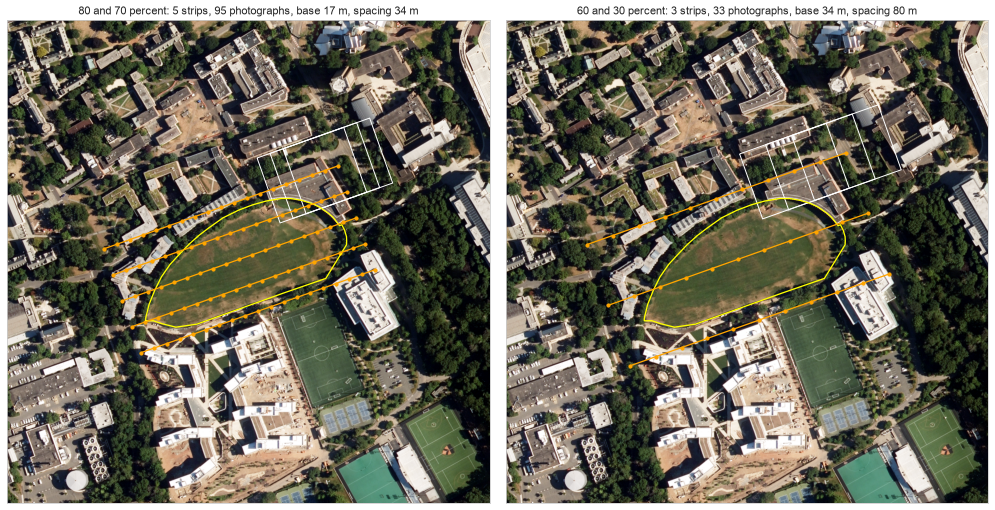

In [6]:
with rasterio.open("data/naip_2022_site.tif") as f:
    rgb = f.read([1, 2, 3]).astype("float32")
    lo, hi = np.percentile(rgb, 1, axis=(1, 2)), np.percentile(rgb, 99, axis=(1, 2))
    rgb = np.moveaxis(np.clip((rgb - lo[:, None, None]) / (hi - lo)[:, None, None], 0, 1), 0, -1)
    extent = (f.bounds.left, f.bounds.right, f.bounds.bottom, f.bounds.top)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
for ax, (forward, side) in zip(axes, ((80, 70), (60, 30))):
    p = plan(ALTITUDE_M, forward, side, field)
    ax.imshow(rgb, extent=extent)
    gpd.GeoSeries(p["footprints"][:3], crs=site.crs).boundary.plot(ax=ax, color="white", linewidth=1)
    site.boundary.plot(ax=ax, color="yellow", linewidth=1.3)
    gpd.GeoSeries(p["strips"], crs=site.crs).plot(ax=ax, color="orange", linewidth=1.3)
    gpd.GeoSeries(p["photos"], crs=site.crs).plot(ax=ax, color="orange", markersize=10)
    ax.set_title(f"{forward} and {side} percent: {p['n_strips']} strips, {p['n_photos']} photographs, base {p['base_m']:.0f} m, spacing {p['spacing_m']:.0f} m", fontsize=11)
    ax.set_xlim(extent[0], extent[1]); ax.set_ylim(extent[2], extent[3]); ax.set_xticks([]); ax.set_yticks([])
fig.tight_layout()

The white boxes are the point of the picture. Each photograph covers almost the whole width of the field, and three photographs a base apart cover nearly the same ground three times, which is what 80 percent forward overlap means. At 60 and 30 percent the strips are more than twice as far apart and the dots twice as far along, and the same lawn is seen from far fewer places.

## The interval the app offers

The plan wants a photograph every 17.1 m, i.e. every 3.4 s at 5 m/s. The aircraft, however, takes timed photographs only at intervals from a menu, and 3.4 s is not on it. The pilot therefore chooses the nearest interval that keeps the overlap at or above the plan, and either accepts the extra photographs or flies faster to get back to the base the plan wanted:

In [7]:
INTERVALS_S = [row["interval_s"] for row in reference["plan"]["intervals"]]     # the aircraft's timed shot menu, read off it on the pre-flight
SPEED = 5.0
p80 = plan(ALTITUDE_M, 80, 70, field)
along = footprint(ALTITUDE_M)[1]
print(f"the plan wants a photograph every {p80['base_m']:.1f} m, i.e. every {p80['interval_s']:.2f} s at {SPEED:.0f} m/s")
for t in INTERVALS_S:
    base = SPEED * t
    overlap_pct = 100 * (1 - base / along)                  # what is left of the frame after the aircraft has moved one base
    speed_for_80 = p80["base_m"] / t                        # or keep 80 percent by flying this fast instead
    print(f"every {t:2d} s at {SPEED:.0f} m/s: base {base:4.0f} m, forward overlap {overlap_pct:5.1f} percent;  for exactly 80 percent fly at {speed_for_80:.2f} m/s")
chosen = reference["plan"]["chosen"]
print(f"chosen: every {chosen['interval_s']} s at {chosen['speed_m_s']} m/s, base {chosen['base_m']} m, {chosen['forward_pct']} percent forward ({chosen['status']})")

the plan wants a photograph every 17.1 m, i.e. every 3.43 s at 5 m/s
every  2 s at 5 m/s: base   10 m, forward overlap  88.3 percent;  for exactly 80 percent fly at 8.57 m/s
every  3 s at 5 m/s: base   15 m, forward overlap  82.5 percent;  for exactly 80 percent fly at 5.71 m/s
every  5 s at 5 m/s: base   25 m, forward overlap  70.8 percent;  for exactly 80 percent fly at 3.43 m/s
every  7 s at 5 m/s: base   35 m, forward overlap  59.2 percent;  for exactly 80 percent fly at 2.45 m/s
every 10 s at 5 m/s: base   50 m, forward overlap  41.7 percent;  for exactly 80 percent fly at 1.71 m/s
chosen: every 3 s at 5.0 m/s, base 15.0 m, 82.5 percent forward (the plan's; the interval menu was confirmed on the pre-flight, which itself flew 5 s)


Every three seconds at 5 m/s gives a base of 15 m and 82.5 percent forward overlap, slightly more than planned and a few more photographs per strip; every two seconds gives 88 percent and nearly twice the photographs; every five seconds drops to 71 percent, below the plan, and is out. The class flight takes the three second interval. Read the status on the last line before you trust it. The three seconds are the plan's choice; the pre-flight of 17 September flew five seconds at 3.7 m/s, and in loops rather than strips, so its overlap along the track is fair but the plan's geometry was not flown at all. Reading the interval actually flown off the photographs' own time stamps is the first thing 03-05 does.

## How many photographs see each cell

Overlap percentages are abstract. Here is the same fact as a map. We lay a grid of 2 m cells over the site, rasterise every photograph's footprint onto it, and add them up, so each cell holds the number of photographs in which that piece of ground appears:

80 and 70 percent: inside the field every cell is in 10 to 21 photographs, 14 in the middle   reference 10 to 21, median 14
60 and 30 percent: inside the field every cell is in 3 to 8 photographs, 3 in the middle   reference 3 to 8, median 3


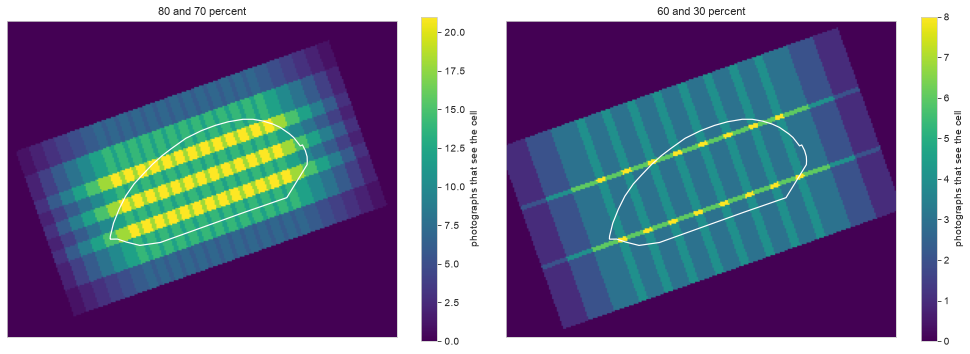

In [8]:
def rays_per_cell(p, field_polygon, cell=2.0, margin=100.0):
    '''How many of a plan's photographs see each cell of a grid over the field, and which cells are inside it.'''
    x0, y0, x1, y1 = field_polygon.minimum_rotated_rectangle.bounds
    x0, y0, x1, y1 = x0 - margin, y0 - margin, x1 + margin, y1 + margin
    n_cols, n_rows = math.ceil((x1 - x0) / cell), math.ceil((y1 - y0) / cell)
    transform = from_origin(x0, y1, cell, cell)
    counts = np.zeros((n_rows, n_cols), dtype="int16")
    for fp in p["footprints"]:
        counts += features.rasterize([(fp, 1)], out_shape=(n_rows, n_cols), transform=transform, fill=0, dtype="int16")
    inside = features.rasterize([(field_polygon, 1)], out_shape=(n_rows, n_cols), transform=transform, fill=0, dtype="uint8").astype(bool)
    return counts, inside, (x0, x1, y0, y1)

maps = {}
for forward, side in ((80, 70), (60, 30)):
    p = plan(ALTITUDE_M, forward, side, field)
    counts, inside, ext = rays_per_cell(p, field)
    maps[(forward, side)] = (counts, inside, ext)
    cov = reference["plan"][f"overlap_{forward}_{side}"]["coverage_inside_site"]
    print(f"{forward} and {side} percent: inside the field every cell is in {counts[inside].min()} to {counts[inside].max()} photographs, "
          f"{np.median(counts[inside]):.0f} in the middle   reference {cov['min']} to {cov['max']}, median {cov['median']}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5.6))
for ax, ((forward, side), (counts, inside, ext)) in zip(axes, maps.items()):
    im = ax.imshow(counts, extent=ext, cmap="viridis", vmin=0, vmax=int(counts[inside].max()))
    site.boundary.plot(ax=ax, color="white", linewidth=1.2)
    ax.set_title(f"{forward} and {side} percent", fontsize=11)
    ax.set_xticks([]); ax.set_yticks([])
    fig.colorbar(im, ax=ax, shrink=0.85, label="photographs that see the cell")
fig.tight_layout()

At 60 and 30 percent most of the field is in three or four photographs, a few cells near the strip edges in more, and two is the minimum for a height at all. At 80 and 70 percent the count inside the field runs from ten into the twenties, in bands where the footprints of neighbouring strips pile up, and even the edges of the field are seen from a dozen places. Hold the two numbers against each other. The formula two sections up said about seventeen photographs per point; the map says ten to twenty one with fourteen in the middle. The formula assumes a field without edges, and the map knows where the edges are, which is what the extra photograph beyond each strip end was for. That is the redundancy that lets the software throw out a bad match and still have a dozen good ones, and it is what sees the ground beside a building that the photograph straight above it cannot.

## What the numbers buy

Three consequences of the plan are worth a number each, because they are what Wednesday's products will show and what 03-06 to 03-08 will measure.

The first is the lean of tall things. A photograph is a central projection, so the top of a building images farther from the centre than its base, by an amount that grows with its height and its distance from the nadir. The lecture worked it for a 20 m building 40 m from the nadir, and the software's orthomosaic will have to correct exactly this:

In [9]:
def relief(h, building_m, offset_m):
    '''Where the top of a building of height building_m, whose base is offset_m from the nadir, images on the ground.'''
    top = offset_m * h / (h - building_m)
    return top, top - offset_m

top, lean = relief(ALTITUDE_M, 20, 40)
print(f"at {ALTITUDE_M:.0f} m a 20 m building 40 m from the nadir images its top where a ground point {top:.1f} m out would, a lean of {lean:.1f} m,"
      f" i.e. {lean / gsd(ALTITUDE_M):.0f} pixels   reference lean {reference['relief']['lean_m']} m")

at 80 m a 20 m building 40 m from the nadir images its top where a ground point 53.3 m out would, a lean of 13.3 m, i.e. 467 pixels   reference lean 13.3 m


Thirteen metres of lean, more than four hundred and sixty pixels, and it points away from the centre of whichever photograph you look at. In a single photograph a roof simply sits in the wrong place. In the orthomosaic, which is the single picture the software builds from all the photographs with every point moved to where a map would put it, the software moves the roof back using a model of the ground, and it moves it only if that model knows the roof is up there. This is why 03-07 spends its time on the difference between a surface and a terrain.

The second is the precision of heights. Two photographs of one point from stations a base apart give its height by parallax, and the precision of that height is the flying height over the base, times the GSD, times how well a point can be located in the photograph, about a third of a pixel. A longer base is a stronger triangle:

In [10]:
def precision(h, forward, pointing_px=0.3, cam=MINI_3):
    '''Base to height ratio and the height precision of one stereo pair, sigma_h = (H / B) GSD sigma_p.'''
    base = footprint(h, cam)[1] * (1 - forward / 100)
    return base / h, (h / base) * gsd(h, cam) * pointing_px

for forward in (60, 80):
    ratio, sigma = precision(ALTITUDE_M, forward)
    print(f"adjacent photographs at {forward} percent: base to height {ratio:.2f}, height precision {sigma * 100:.1f} cm")
print(f"reference {reference['precision']['sigma_h_cm_60']} cm at 60 and {reference['precision']['sigma_h_cm_80']} cm at 80 percent")
print(f"the lecture's {reference['precision']['sigma_h_cm_60']} cm is the 60 percent pair; at 80 percent the software pairs photographs two apart and gets the same base back")
a = reference["accuracy_table"]
print(f"with surveyed control a block at {ALTITUDE_M:.0f} m would place points to {a['plan_mm']} mm in plan and {a['height_mm']} mm in height, a spot height to {a['spot_cm']} cm,"
      f" and a target would need to span about ten pixels, {reference['target_cm']} cm")

adjacent photographs at 60 percent: base to height 0.43, height precision 2.0 cm
adjacent photographs at 80 percent: base to height 0.21, height precision 4.0 cm
reference 2.0 cm at 60 and 4.0 cm at 80 percent
the lecture's 2.0 cm is the 60 percent pair; at 80 percent the software pairs photographs two apart and gets the same base back
with surveyed control a block at 80 m would place points to 5.3 mm in plan and 8.0 mm in height, a spot height to 1.6 cm, and a target would need to span about ten pixels, 29 cm


Four centimetres from adjacent photographs at 80 percent and two from the 60 percent pair, because the wider pair has a base twice as long. This is not an argument against overlap. At 80 percent the software also pairs each photograph with the one two along, whose base is the 34 m of the classical plan, and it has a dozen such pairs per point, so it gets the two centimetres and the redundancy both. It is only a warning against reading a single percentage as a single precision.

The third consequence is the one we give up. The last line describes what a flight with surveyed ground control targets could achieve, millimetres in plan and in height and a spot height to a centimetre and a half, and the size of the targets it would need. The class flight lays no targets. The block, which is what photogrammetry calls all the photographs of a flight solved together as one rigid thing, is placed on the Earth by the drone's own satellite receiver, which knows where it is to a metre or two. So the orthomosaic will be sharp to a few centimetres and placed to metres, and 03-08 measures exactly that gap against the federal and the State's photographs of the same ground.

## Your turn

Replan the flight twice. First at 60 m instead of 80, at the same 80 and 70 percent. Second at 80 m but in the camera's 48 megapixel mode, in which the pixel is 1.2 micrometres and the photograph 8000 by 6000, and the shortest interval the aircraft allows between photographs is five seconds. For each, report the strips, the photographs and the GSD. Then, for the 12 megapixel mode, the fastest speed that still gives 80 percent forward overlap at each interval on the menu, and one sentence on why the 48 megapixel mode cannot be flown at 5 m/s at all.

`plan` and `gsd` take the camera as their `cam` argument, so the second replan is one new dictionary and one call.

The cell below has the lines with blanks. Fill them, remove the `#` at the start of each line, and run it. There is no class answer on the board.

In [11]:
# Your attempt. Fill the blanks, then delete the # at the start of each line and run.
#
# p60 = plan(___, 80, 70, field)
# print(p60["n_strips"], "strips of", p60["n_per_strip"], ",", p60["n_photos"], "photographs at", round(gsd(___) * 100, 2), "cm")
#
# MINI_3_48 = dict(MINI_3, pixel_um=___, width_px=___, height_px=___, min_interval_s=5)
# p48 = plan(80, 80, 70, field, cam=MINI_3_48)
# print(p48["n_photos"], "photographs at", round(gsd(80, MINI_3_48) * 100, 2), "cm, needing a photograph every", round(p48["interval_s"], 2), "s at 5 m/s")
#
# for t in INTERVALS_S:
#     print("every", t, "s: at most", round(p80["base_m"] / t, 2), "m/s for 80 percent")

## Check your understanding

1. The GSD at 80 m is 2.86 cm. Without running anything, what is it at 40 m, and why is the answer exact rather than approximate?
2. Two plans cover the same field, one at 60 and 30 percent and one at 80 and 70. Which numbers in `densities` change and which do not, and what does the ratio of their `per_km2` values tell you about the flight time?
3. `plan` adds one extra photograph beyond each end of each strip. What would go wrong at the ends of the field without them, and why is the same trick not needed at the sides?
4. The adjacent pair at 80 percent gives a poorer height than the pair at 60 percent, yet the 80 percent flight produces better heights overall. Reconcile the two statements.

## Where we are

You can turn a camera's pixel and focal length and a height into a GSD and a footprint, two overlaps into a base and a spacing, and a site polygon into strips, photographs, a path and a time, and you have done it for Wednesday's flight and found the lecture's numbers. You can draw a plan on a map and count how often each square metre of the ground is photographed. You know how far a roof leans in a single photograph, how the base decides the precision of a height, and what a flight without ground control can and cannot promise.

The habit worth keeping: before you fly, or before you trust somebody else's flight, compute the GSD, the base, the spacing and the count from the camera and the site, and compare them with what the app proposes.

In 03-04 we turn to the ground the drone will fly over, the federal one metre terrain model, and get our first heights from a hillshade, a section and a shadow.

## Further resources

Nothing in this course requires anything below.

The flight planning algebra is chapter 18 of Wolf, Dewitt and Wilkinson, Elements of Photogrammetry (4th edition), on the course reading list, and the overlap recommendations for drone mapping are on the OpenDroneMap documentation's flying page: https://docs.opendronemap.org/flying/

The rules a small drone flies under in the United States are the FAA's Part 107: https://www.faa.gov/uas/commercial_operators/part_107. The camera's specifications are published by the manufacturer: https://www.dji.com/mini-3/specs

The GETSI teaching module on structure from motion has a field protocol for flight planning and ground control, which we follow in spirit and cite rather than copy, since its licence is CC BY-NC-SA: https://serc.carleton.edu/getsi/teaching_materials/high-rez-topo/index.html

The site outline is an OpenStreetMap extract, licensed ODbL 1.0, copyright OpenStreetMap contributors: https://www.openstreetmap.org/copyright. The 2022 aerial photograph is USDA NAIP, public domain.

## Appendix, in case you are stuck

Try properly first. If you do use these, treat them the way you would treat an agent's answer. Read them, run them, and say why yours differed.

The two replans and the speed table. The cell stands on its own, so it repeats the four functions of the notebook in their shortest form:

```python
import math
import numpy as np
import geopandas as gpd
from shapely.geometry import LineString, Point, box
from shapely.affinity import rotate

MINI_3 = dict(pixel_um=2.4, focal_mm=6.72, width_px=4000, height_px=3000, min_interval_s=2)

def gsd(h, cam=MINI_3):
    return cam["pixel_um"] * 1e-6 * h / (cam["focal_mm"] * 1e-3)

def footprint(h, cam=MINI_3):
    return cam["width_px"] * gsd(h, cam), cam["height_px"] * gsd(h, cam)

def densities(h, forward, side, cam=MINI_3):
    across, along = footprint(h, cam)
    base, spacing = along * (1 - forward / 100), across * (1 - side / 100)
    return dict(base_m=base, spacing_m=spacing, neat_m2=base * spacing, per_km2=1e6 / (base * spacing), base_to_height=base / h)

def plan(h, forward, side, field_polygon, cam=MINI_3, speed=5.0):
    rect = field_polygon.minimum_rotated_rectangle
    corners = np.array(rect.exterior.coords)[:4]
    edges = np.roll(corners, -1, axis=0) - corners
    k = int(np.argmax(np.hypot(edges[:, 0], edges[:, 1])))
    angle, centre = math.degrees(math.atan2(edges[k, 1], edges[k, 0])), rect.centroid
    minx, miny, maxx, maxy = rotate(rect, -angle, origin=centre).bounds
    d = densities(h, forward, side, cam)
    n_strips, n_per_strip = math.ceil((maxy - miny) / d["spacing_m"]) + 1, math.ceil((maxx - minx) / d["base_m"]) + 1
    photos = [rotate(Point(centre.x - (n_per_strip - 1) * d["base_m"] / 2 + i * d["base_m"], centre.y - (n_strips - 1) * d["spacing_m"] / 2 + s * d["spacing_m"]), angle, origin=centre)
              for s in range(n_strips) for i in range(-1, n_per_strip + 1)]
    return dict(n_strips=n_strips, n_per_strip=n_per_strip, n_photos=len(photos), interval_s=d["base_m"] / speed, **d)

field = gpd.read_file("data/site.gpkg", layer="site").to_crs("EPSG:26918").geometry.iloc[0]
p80 = plan(80, 80, 70, field)
p60 = plan(60, 80, 70, field)
print(p60["n_strips"], "strips of", p60["n_per_strip"], ",", p60["n_photos"], "photographs at", round(gsd(60) * 100, 2), "cm")

MINI_3_48 = dict(MINI_3, pixel_um=1.2, width_px=8000, height_px=6000, min_interval_s=5)
p48 = plan(80, 80, 70, field, cam=MINI_3_48)
print(p48["n_photos"], "photographs at", round(gsd(80, MINI_3_48) * 100, 2), "cm, needing a photograph every", round(p48["interval_s"], 2), "s at 5 m/s")

for t in (2, 3, 5):
    print("every", t, "s: at most", round(p80["base_m"] / t, 2), "m/s for 80 percent")
```

At 60 m the footprint shrinks with the GSD, so the base and the spacing shrink too and the count rises to six strips of twenty three, 150 photographs at 2.14 cm. In the 48 megapixel mode the footprint is unchanged, since twice the pixels at half the size cover the same ground, so the plan is the same 95 photographs at an arithmetic 1.43 cm. Treat that number with care. This sensor reads its 48 megapixels off the same photosites by a quad Bayer trick, so the extra detail is interpolated rather than measured, and the pixel you can resolve is nearer the 12 megapixel mode's than the arithmetic says; but it still wants a photograph every 3.43 s, and that mode cannot take one faster than every five seconds, so at 5 m/s the overlap would fall to 71 percent. The aircraft would have to slow to 3.43 m/s, and the flight would take half again as long for four times the data.